## WorldView Scene-Combination Benchmark, Full Scenes: SpaceNet Atlanta

The [scene-combination benchmark](https://asp-plot.readthedocs.io/en/latest/examples/notebooks/worldview_spacenet_benchmark.html) scored 21 Atlanta DEMs made from a cropped window of five same-pass WorldView-2 scenes, and wrote three practical rules from them (uw-cryo/asp_plot#169, scoring revised in #205). This notebook repeats the core of that experiment on the **full strips** (uw-cryo/asp_plot#207) to test whether the rules hold where the crop could not test them:

- along the whole strip, where viewing geometry, sun angle and land cover change along track;
- for coverage and edge behaviour of a joint multi-view run against a pairwise mosaic, including where only some scenes overlap;
- for along-track camera errors (jitter), which a small crop averages out and a `pc_align` translation cannot remove;
- with many more ICESat-2 tracks per DEM, which the paired track bootstrap needs to separate candidates.

### Key takeaways

Twenty-one full-strip DEMs, scored on 38 305 ICESat-2 points of stable terrain valid in all of them, over a 421 km² common footprint (the crop was 38 km²):

1. **Convergence still sets single-pair accuracy (rule 3 holds).** NMAD is 1.5–1.7 m at ~5°, 1.20 m at 10°, 0.95 m at 17°, and flat from 22° to 32°: 0.88–0.91 m mapprojected, 0.76–0.78 m raw.
2. **Pairwise + mosaic matches multi-view only without the weak pairs (rule 2 holds).** Blends of the ten pairs: plain average 1.08 m, without the pairs below 15° 0.86 m, median 0.87 m. The joint multi-view runs score 0.87–0.88 m. At strip scale the curated blends match the joint runs rather than beat them.
3. **The reference scene no longer matters (rule 1 does not hold over the strip).** Multi-view with reference nadir10 scores 0.87 m and with nadir13 0.88 m: 0.01 m apart, well inside their intervals. The cropped study's advantage for nadir10 (0.53 vs 0.61 m) belongs to the airport window: clipped to that window, the full-strip runs keep the same order (0.54 vs 0.58 m), but within each other's intervals.
4. **The best full-strip DEM is a single wide raw pair: 10-21 at 0.76 m.**
    - Raw beats mapprojected by 0.11–0.15 m at 22–32°, and covers 3–5 % less.
    - At ~5° the order reverses: mapprojected is 0.06–0.09 m better.
    - The raw advantage is largest where COP30 is farthest from the surface the images see (downtown, the north of the strips). Mapprojection onto a 30 m reference costs accuracy there.
5. **On the cropped study's own ground, the full strips reproduce it.** Every DEM clipped to the airport box scores within −0.29 to +0.09 m of its cropped counterpart, mostly within 0.1 m. The larger extent does not degrade the result; the strip-scale ranking differs because of the rest of the strip.
6. **Along-track camera errors are real at strip scale.** On 2–5 km scales the median residual swings by ±0.2–0.3 m, and the swings follow the scenes. Every DEM that contains scenes 10 and 21 shares one pattern, raw and mapprojected alike; pairs without them show another. All DEMs also share a ~0.4 m south-to-north tilt. A `pc_align` translation removes neither, and a crop averages both out.
7. **Score full scenes on stable terrain.** Almost half of the ICESat-2 points over the strips fall on trees. Keeping them roughly doubles every NMAD and dilutes the differences between DEMs.

**Scope.** One flat, urban, same-pass site and one altimetry sample. The multi-view runs and blends are mapprojected only. Raw stereo was run for six of the ten pairs: it costs about twice as much on a full strip, ~30 SBU per pair, because its disparity search grows to 190 × 127 px. The whole round used about 450 SBU on the NASA NAS supercomputer. Follow-ups are listed at the end.

The three rules under test, from the cropped study:

1. For a multi-view run, use a scene at one end of the pass as the reference, not the middle: it gives the widest *star* of reference-to-scene pairs.
2. For a pairwise flow, drop pairs below ~15° rather than down-weighting them; if pairs cannot be vetted, blend with `--median`.
3. Single-pair accuracy is set by convergence angle for same-pass data (the convergence curve).

---

## Testbed

The same five scenes as the cropped study (2009-12-22, SpaceNet AOI 6, `s3://spacenet-dataset/AOIs/AOI_6_Atlanta/metadata/<CATID>/`), now with every PAN L1B tile of each collect. Every CATID is delivered as three tiles (`P001`–`P003`); the cropped study used the one tile that contained the airport. Here each tile is `wv_correct`ed and the three are mosaicked with `dg_mosaic` into one strip per CATID (`<CATID>.r100.tif`), using dgtools `ntfmos.sh`:

```bash
# per CATID dir holding <CATID>_P1BS_P00{1,2,3}.{tif,xml}
wv_correct --threads 2 <tile>.tif <tile>.xml <tile>_corr.tif        # each tile
dg_mosaic --input-nodata-value 5 --output-nodata-value 0 --ignore-inconsistencies \
    --output-prefix <CATID> <CATID>_P1BS_P00{1,2,3}_corr.tif         # -> <CATID>.r100.{tif,xml}
```

The tiles overlap along track, and `dg_mosaic` places them by their first-line time rather than stacking them end to end. That also maps the cropped study's crop windows onto the strips: tile `P002` of nadir13 starts at line (16:36:01.322775 − 16:36:00.344175 s) × 20 000 lines/s = 19 572 of its strip, so the reference crop `5879 13107 12981 11894` is `5879 32679 12981 11894` here. Projecting the airport box through each strip's RPC gives the same offset to one line.

Processing ran on the NASA NAS (Pleiades) supercomputer with ASP 3.7.0; the cropped study ran on a laptop with ASP 3.8.0-alpha.

In [1]:
import os
import re
from glob import glob

import numpy as np
import pandas as pd

# Set the base directory for your processing
directory = "/nobackup/bpurint1/data/atlanta/WV/20091222_spacenet/full_benchmark/"
directory = os.path.expanduser(directory)
tiles_dir = os.path.dirname(os.path.dirname(directory)) + "/"

# Along-track order 10, 8, 13, 16, 21 (SpaceNet collect names give the nominal off-nadir angle)
SCENES = {
    "1030010003CAF100": "10",
    "10300100023BC100": "8",
    "1030010002B7D800": "13",
    "1030010002649200": "16",
    "1030010003127500": "21",
}


def xml_value(xml, tag):
    m = re.search(f"<{tag}>([^<]+)</{tag}>", open(xml).read())
    return m.group(1) if m else None


rows = []
for catid, name in SCENES.items():
    xml = f"{directory}{catid}.xml"
    tiles = sorted(glob(f"{tiles_dir}{catid}/{catid}_P1BS_P00?.xml"))
    rows.append(
        {
            "name": f"nadir{name}",
            "catid": catid,
            "tiles": len(tiles),
            "lines": int(xml_value(xml, "NUMROWS")),
            "samples": int(xml_value(xml, "NUMCOLUMNS")),
            "off-nadir (deg)": float(xml_value(xml, "MEANOFFNADIRVIEWANGLE")),
            "GSD (m)": float(xml_value(xml, "MEANPRODUCTGSD")),
            "first line (UTC)": xml_value(xml, "FIRSTLINETIME"),
        }
    )
scenes = pd.DataFrame(rows).sort_values("first line (UTC)").reset_index(drop=True)
scenes

,name,catid,tiles,lines,samples,off-nadir (deg),GSD (m),first line (UTC)
0,nadir21,1030010003127500,3,52951,35180,21.466667,0.529667,2009-12-22T16:35:43.389975Z
1,nadir16,1030010002649200,3,56952,35180,17.100000,0.504667,2009-12-22T16:35:54.389975Z
2,nadir13,1030010002B7D800,3,52952,35180,13.966667,0.491667,2009-12-22T16:36:00.344175Z
3,nadir8,10300100023BC100,3,56951,35180,8.300000,0.475333,2009-12-22T16:36:33.989775Z
4,nadir10,1030010003CAF100,3,56956,35180,10.633333,0.481000,2009-12-22T16:36:39.943775Z


### Footprints

Each strip's footprint is the union of its tiles' corner polygons. The cropped study's airport window is a small part of the area all five strips cover, and the ICESat-2 sample (requested once over the union of the footprints and replayed for every DEM) crosses the strips on four reference ground tracks. Their repeat passes are spread across several kilometres, not stacked on one line, so the 226 beam tracks sample most of the common footprint; the cropped study's window held 52 of them.

name,nadir10,nadir8,nadir13,nadir16,nadir21
area (km²),461.0,450.0,447.0,509.0,522.0


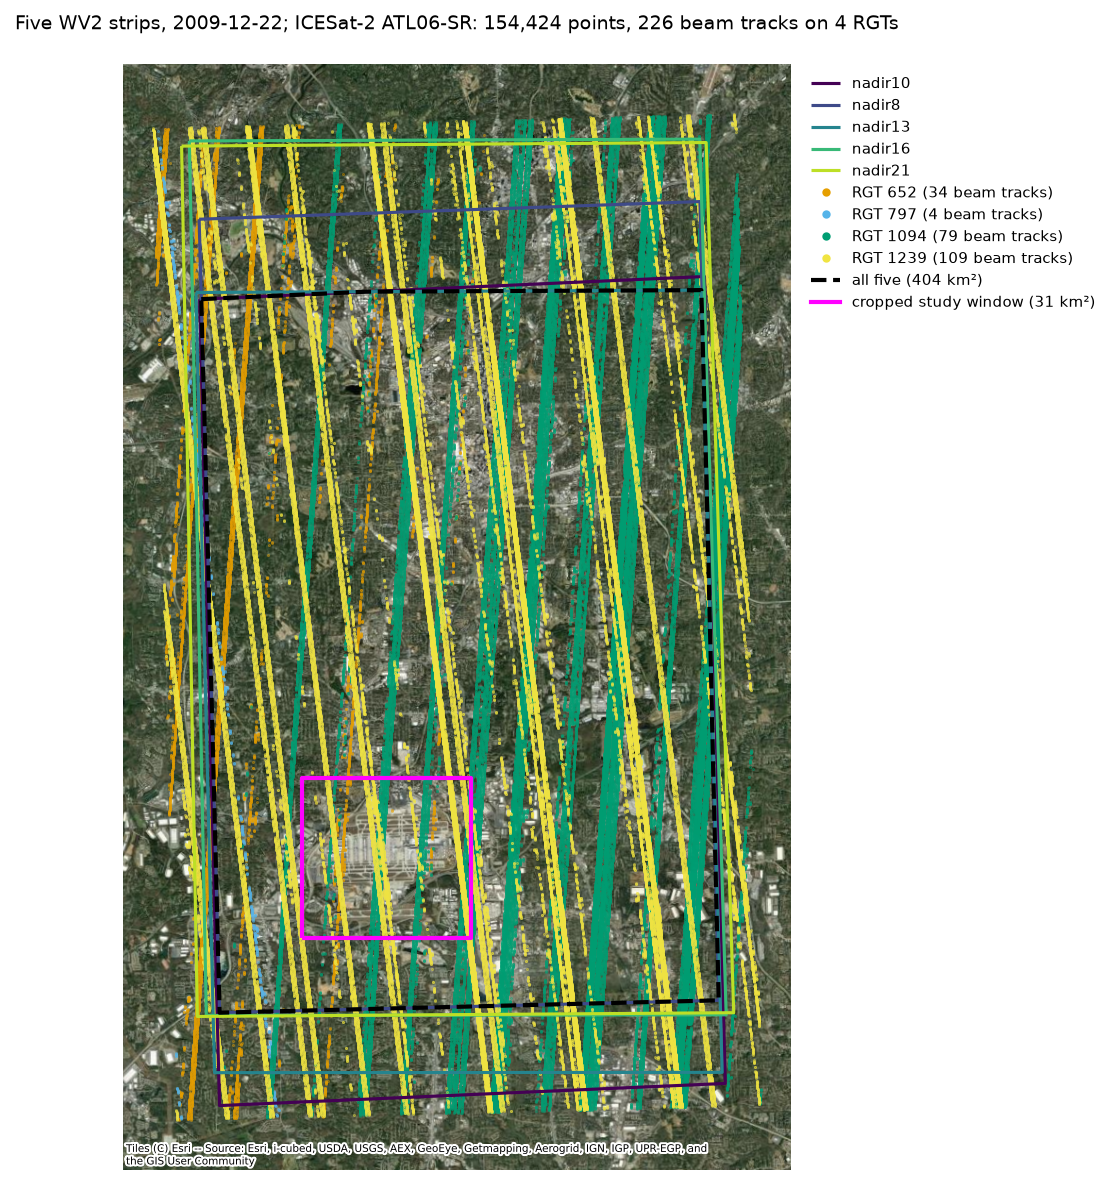

In [2]:
import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely import union_all
from shapely.geometry import Polygon, box


def tile_polygon(xml):
    s = open(xml).read()
    corner = lambda c: (
        float(re.search(f"<{c}LON>([^<]+)<", s).group(1)),
        float(re.search(f"<{c}LAT>([^<]+)<", s).group(1)),
    )
    return Polygon([corner(c) for c in ("UL", "UR", "LR", "LL")])


utm = "EPSG:32616"
fp = gpd.GeoDataFrame(
    {
        "name": [f"nadir{SCENES[c]}" for c in SCENES],
        "geometry": [
            union_all([tile_polygon(x) for x in glob(f"{tiles_dir}{c}/{c}_P1BS_P00?.xml")])
            for c in SCENES
        ],
    },
    crs="EPSG:4326",
).to_crs(utm)
common = gpd.GeoSeries([fp.geometry.intersection_all()], crs=utm)
crop = gpd.GeoSeries([box(735685, 3722295, 741350, 3727695)], crs=utm)

atl = gpd.read_parquet(f"{directory}atl06sr_all.parquet").to_crs(utm)
n_tracks = atl.groupby(["rgt", "cycle", "spot"]).ngroups

fig, ax = plt.subplots(figsize=(9, 8), dpi=150)
for (_, r), color in zip(fp.iterrows(), plt.cm.viridis(np.linspace(0, 0.9, len(fp)))):
    gpd.GeoSeries([r.geometry], crs=utm).boundary.plot(ax=ax, color=color, lw=1.5, label=r["name"], zorder=3)
common.boundary.plot(ax=ax, color="k", lw=2, ls="--", zorder=4)
crop.boundary.plot(ax=ax, color="magenta", lw=2, zorder=4)
for rgt, color in zip(sorted(atl.rgt.unique()), ["#e69f00", "#56b4e9", "#009e73", "#f0e442"]):
    sub = atl[atl.rgt == rgt]
    sub.plot(ax=ax, color=color, markersize=0.2, alpha=0.5, zorder=2)
    ax.plot([], [], ".", color=color, label=f"RGT {rgt} ({sub.groupby(['cycle', 'spot']).ngroups} beam tracks)")
ax.plot([], [], "k--", lw=2, label=f"all five ({common.area.iloc[0] / 1e6:.0f} km²)")
ax.plot([], [], color="magenta", lw=2, label=f"cropped study window ({crop.area.iloc[0] / 1e6:.0f} km²)")
ctx.add_basemap(ax, crs=utm, source=ctx.providers.Esri.WorldImagery, attribution_size=5)
ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)
ax.set_title(
    f"Five WV2 strips, 2009-12-22; ICESat-2 ATL06-SR: {len(atl):,} points, "
    f"{n_tracks} beam tracks on {atl.rgt.nunique()} RGTs",
    fontsize=9,
)
ax.set_axis_off()
fig.tight_layout()

pd.DataFrame(
    {"area (km²)": [g.area / 1e6 for g in fp.geometry]}, index=fp["name"]
).round(0).T

---

## Bundle adjustment

One `bundle_adjust` of the five full strips, the camera network that every stereo run below shares, with the cropped study's settings except for the number of interest points. That study adjusted single tiles with `--ip-per-image 10000`; a strip is three tiles, so `--ip-per-image 30000` keeps the same density per km².

```bash
bundle_adjust -t dg --threads 28 \
    --ip-per-image 30000 --tri-weight 0.1 --tri-robust-threshold 0.1 --camera-weight 0 \
    1030010002B7D800.tif 10300100023BC100.tif 1030010003CAF100.tif 1030010002649200.tif 1030010003127500.tif \
    1030010002B7D800.xml 10300100023BC100.xml 1030010003CAF100.xml 1030010002649200.xml 1030010003127500.xml \
    -o ba/run
```

It took 70 minutes on one 28-core Broadwell node; the median reprojection error after adjustment is 0.20–0.21 px for every camera (0.21 px in the cropped study).

The convergence angles over the full strips are within 0.7° of the cropped study's, so the experiment keeps its design: ten pairs spread from about 5° to 32°, the same six pairs above 15°, and the same two reference stars.

In [3]:
# ba/run-convergence_angles.txt: left right 25% 50% 75% num_matches (degrees)
conv = pd.read_csv(
    f"{directory}ba/run-convergence_angles.txt",
    sep=r"\s+",
    comment="#",
    names=["left", "right", "p25", "p50", "p75", "num_matches"],
)
for col in ("left", "right"):
    conv[col] = conv[col].str.replace(".tif", "", regex=False).map(SCENES)
conv["pair"] = conv["left"] + "-" + conv["right"]

# The cropped study's convergence (worldview_spacenet_benchmark.ipynb), BA of the single tiles
crop_p50 = {"13-16": 5.12, "16-21": 5.36, "8-10": 5.46, "13-21": 10.51, "13-8": 16.33,
            "8-16": 21.47, "13-10": 21.79, "8-21": 26.83, "10-16": 26.93, "10-21": 32.29}
key = lambda p: p if p in crop_p50 else "-".join(p.split("-")[::-1])
conv["crop p50"] = conv["pair"].map(lambda p: crop_p50[key(p)])
conv = conv.sort_values("p50").reset_index(drop=True)
conv[["pair", "p50", "p25", "p75", "crop p50", "num_matches"]].rename(
    columns={"p50": "convergence (deg)"}
).round(2)

,pair,convergence (deg),p25,p75,crop p50,num_matches
0,13-16,4.51,3.96,5.15,5.12,11432
1,8-10,4.79,4.10,5.51,5.46,11507
2,16-21,5.45,5.37,5.52,5.36,11073
3,13-21,9.93,9.42,10.49,10.51,9948
4,13-8,16.97,16.26,17.65,16.33,10081
5,8-16,21.59,21.48,21.69,21.47,9143
6,13-10,21.79,21.78,21.80,21.79,9616
7,10-16,26.28,25.69,26.93,26.93,6514
8,8-21,27.04,26.85,27.20,26.83,5298
9,10-21,31.72,31.18,32.27,32.29,3995


---

## Processing

Staged, as proposed in #207: one round that is enough to test the three Atlanta rules at strip scale.

| Run | Scenes (reference first) | Tests |
|---|---|---|
| ten pairs | every combination | rule 3, the convergence curve |
| MVS 5 ref nadir13 | 13, 8, 10, 16, 21 | rule 1: star 4.5 / 9.9 / 17.0 / 21.8° |
| MVS 5 ref nadir10 | 10, 13, 8, 16, 21 | rule 1: star 4.8 / 21.8 / 26.3 / 31.7° |
| `dem_mosaic` of all ten pairs, of the six > 15°, and `--median` of all ten | | rule 2 |

**Two stereo modes.** The cropped study ran raw-image stereo:
`parallel_stereo --stereo-algorithm asp_mgm --subpixel-mode 9 --alignment-method affineepipolar --bundle-adjust-prefix ba/run`, then `point2dem --tr 1.9 --t_srs EPSG:32616 --errorimage`.
The usual recipe for full scenes mapprojects first: every strip onto Copernicus GLO-30 (ellipsoid heights) at 0.5 m with the adjusted cameras, then `--alignment-method none` with the same correlator and gridding. The whole round above was run **mapprojected**. Six pairs were also run **raw**: the three at ~5° (13-16, 8-10, 16-21) and the three at 22–32° (13-10, 8-21, 10-21), so both ends of the convergence curve exist in both modes.

**Why not all raw: cost on a full strip.** One affine transform cannot rectify a 50 km strip. Up to about 60 px of vertical parallax remains, and the disparity search grows from 90 × 22 px on the crop to 190 × 127 px on the strip. MGM's cost grows with the search area, so a raw strip pair needed ~25 min per 2048² tile and ~30 SBU on 8 Broadwell nodes. Mapprojected, the search is 76 × 102 px (COP30 sits tens of metres from the surface the images see over downtown towers and tree canopy) and a pair costs ~15 SBU. A five-scene multi-view run costs ~4× a pair: ~5 h on 10 nodes mapprojected.

**What the full strips needed that the crop did not**, on the NASA NAS supercomputer:
- Each run was three chained PBS jobs: a 1-node `stereo_pprc`, then an 8–10 node correlation through triangulation, then a 1-node `point2dem`. No node sits idle during the single-node steps.
- Each run also carried a continuation, which resumes at correlation and keeps the finished tiles. It was used four times:
    - a walltime overrun;
    - a Lustre client fault;
    - a lost node;
    - a node that hung a job without failing it.
- ASP 3.7.0's `parallel_stereo` refuses `--keep-only` for multi-view runs. A five-scene run keeps ~150 000 per-tile files (~260 GB) until triangulation.
- A multi-view run stopped after preprocessing fails in its joint tiling step, which needs `<prefix>-L.tif` before ASP creates it. The driver makes that link up front.
- Every finished run was archived to tape with its `F.tif` and `PC.tif`, then trimmed on disk to the DEM and small files.

**Smoke test.** Before the full runs, pair 13-10 was run on the strips cropped to the cropped study's window. It gave NMAD 0.72 m against the laptop's 0.70 m on the same window, so the NAS mosaics, ASP 3.7.0 and the strip-wide bundle adjustment reproduce the cropped result.

---

## Scoring every DEM on stable terrain

The ICESat-2 sample covers the five strips, so most of it falls outside the airport and much of it on forest. Under canopy a stereo DSM and a 40 m ICESat-2 segment measure different surfaces, and the canopy has changed in the decade between the imagery (2009) and the altimetry (2018–2026). On the first full-strip DEM, dropping tree returns as well as water halved the NMAD (1.53 → 0.82 m for raw pair 13-10), with almost half of the points removed. Every full-strip score below is therefore on **stable terrain**: ESA WorldCover water and trees dropped (`filter_out=["water", "trees"]`, the choice recommended in #208). The comparison on the cropped study's window, further down, uses water only, as that study did.

All 21 DEMs are scored together, on the points valid in every one of them, with intervals from 1000 replicates resampling whole beam tracks.

In [4]:
from asp_plot.dem_benchmark import DEMBenchmark

conv_of = dict(zip(conv["pair"], conv["p50"]))


def pair_dir(mode, a, b):
    """<mode>/stereo_pair_<A>_<B>, in either order of the two scene names."""
    for left, right in ((a, b), (b, a)):
        d = f"{directory}{mode}/stereo_pair_{left}_{right}"
        if os.path.isdir(d):
            return d
    return None


candidates = {}
for mode, prefix in (("map", "pair"), ("raw", "raw pair")):
    for r in conv.itertuples():
        d = pair_dir(mode, r.left, r.right)
        if d and os.path.exists(f"{d}/run-DEM.tif"):
            candidates[f"{prefix} {r.pair} ({r.p50:.1f}°)"] = f"{d}/run-DEM.tif"
candidates.update(
    {
        "MVS 5 ref nadir13": f"{directory}map/stereo_mvs5_ref13/run-DEM.tif",
        "MVS 5 ref nadir10": f"{directory}map/stereo_mvs5_ref10/run-DEM.tif",
        "10 pairs + mosaic": f"{directory}map/pairwise10_mosaic-DEM.tif",
        "6 pairs > 15° + mosaic": f"{directory}map/pairwise_wide6_mosaic-DEM.tif",
        "10 pairs + median mosaic": f"{directory}map/pairwise10_median_mosaic-DEM.tif",
    }
)
existing = {k: v for k, v in candidates.items() if os.path.exists(v)}
pending = [k for k in candidates if k not in existing]
print(f"{len(existing)} of {len(candidates)} candidates on disk; pending: {pending}\n")

bench = DEMBenchmark(
    directory=directory,
    dems=existing,
    parquet=f"{directory}atl06sr_all.parquet",
    reference="MVS 5 ref nadir13",
    filter_out=["water", "trees"],
    title="Atlanta WV2 2009-12-22, full strips: pairs (mapprojected and raw), multi-view and blends",
)
import contextlib
import io


def run_quietly(b):
    """Run a benchmark, keeping only its per-DEM summary lines (pc_align is verbose)."""
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        out = b.run()
    keep = ("=== [", "altimetry points", "after pc_align", "valid in every DEM", "Paired bootstrap")
    print("\n".join(line for line in buf.getvalue().splitlines() if any(k in line for k in keep)))
    return out


stats = run_quietly(bench)
stats.drop(columns=["dem_fn", "gsd_m", "north_shift_m", "east_shift_m", "down_shift_m"]).round(2)

21 of 21 candidates on disk; pending: []



=== [1/21] pair 13-16 (4.5°): /nobackup/bpurint1/data/atlanta/WV/20091222_spacenet/full_benchmark/map/stereo_pair_13_16/run-DEM.tif
  45820 altimetry points: median +0.80 m, NMAD 1.74 m
  after pc_align (|t| = 1.00 m): median +0.06 m, NMAD 1.74 m
=== [2/21] pair 8-10 (4.8°): /nobackup/bpurint1/data/atlanta/WV/20091222_spacenet/full_benchmark/map/stereo_pair_10_8/run-DEM.tif
  44939 altimetry points: median +0.98 m, NMAD 1.63 m
  after pc_align (|t| = 1.34 m): median +0.09 m, NMAD 1.62 m
=== [3/21] pair 16-21 (5.4°): /nobackup/bpurint1/data/atlanta/WV/20091222_spacenet/full_benchmark/map/stereo_pair_16_21/run-DEM.tif
  53930 altimetry points: median -0.52 m, NMAD 1.81 m
  after pc_align (|t| = 0.78 m): median -0.15 m, NMAD 1.80 m
=== [4/21] pair 13-21 (9.9°): /nobackup/bpurint1/data/atlanta/WV/20091222_spacenet/full_benchmark/map/stereo_pair_13_21/run-DEM.tif
  45257 altimetry points: median +0.18 m, NMAD 1.32 m
  after pc_align (|t| = 0.81 m): median -0.02 m, NMAD 1.31 m
=== [5/21] pai

,label,valid_pct,valid_area_km2,ie_median_m,ie_nmad_m,n_points,dh_median_m,dh_nmad_m,dh_rmse_m,translation_m,...,dh_aligned_shared_rmse_m,median_ci_low_m,median_ci_high_m,nmad_ci_low_m,nmad_ci_high_m,nmad_vs_best_ci_low_m,nmad_vs_best_ci_high_m,p_best,vs_ref_median_m,vs_ref_nmad_m
0,pair 13-16 (4.5°),97.38,409.98,0.06,0.06,45820,0.80,1.74,2.92,1.00,...,2.21,0.04,0.16,1.54,1.65,0.80,0.88,0.0,-0.42,1.36
1,pair 8-10 (4.8°),95.54,402.21,0.06,0.05,44939,0.98,1.63,2.89,1.34,...,2.16,0.07,0.16,1.44,1.52,0.69,0.76,0.0,-0.34,1.38
2,pair 16-21 (5.4°),98.46,414.51,0.06,0.06,53930,-0.52,1.81,2.87,0.78,...,2.09,-0.30,-0.20,1.50,1.58,0.76,0.82,0.0,0.88,1.31
3,pair 13-21 (9.9°),96.36,405.69,0.08,0.07,45257,0.18,1.32,2.49,0.81,...,1.99,-0.04,0.05,1.16,1.24,0.42,0.47,0.0,0.08,0.69
4,pair 13-8 (17.0°),93.95,395.50,0.08,0.07,44126,0.15,1.08,2.41,1.09,...,1.96,0.02,0.07,0.91,0.99,0.18,0.22,0.0,0.16,0.37
5,pair 8-16 (21.6°),93.67,394.35,0.08,0.08,47596,0.39,1.05,2.48,1.09,...,1.97,-0.01,0.04,0.87,0.95,0.14,0.18,0.0,-0.09,0.38
6,pair 13-10 (21.8°),94.54,398.02,0.09,0.08,47650,0.42,0.98,2.34,0.76,...,1.96,0.03,0.08,0.85,0.93,0.12,0.15,0.0,-0.06,0.27
7,pair 10-16 (26.3°),93.68,394.40,0.10,0.08,44508,0.56,0.98,2.43,0.94,...,1.98,-0.00,0.05,0.84,0.92,0.11,0.15,0.0,-0.24,0.41
8,pair 8-21 (27.0°),92.03,387.46,0.09,0.08,47097,0.25,1.03,2.44,0.68,...,1.99,-0.05,0.01,0.86,0.95,0.14,0.17,0.0,0.06,0.44
9,pair 10-21 (31.7°),92.51,389.45,0.11,0.10,44015,0.41,0.98,2.38,0.70,...,1.99,-0.02,0.03,0.86,0.94,0.13,0.16,0.0,-0.09,0.48


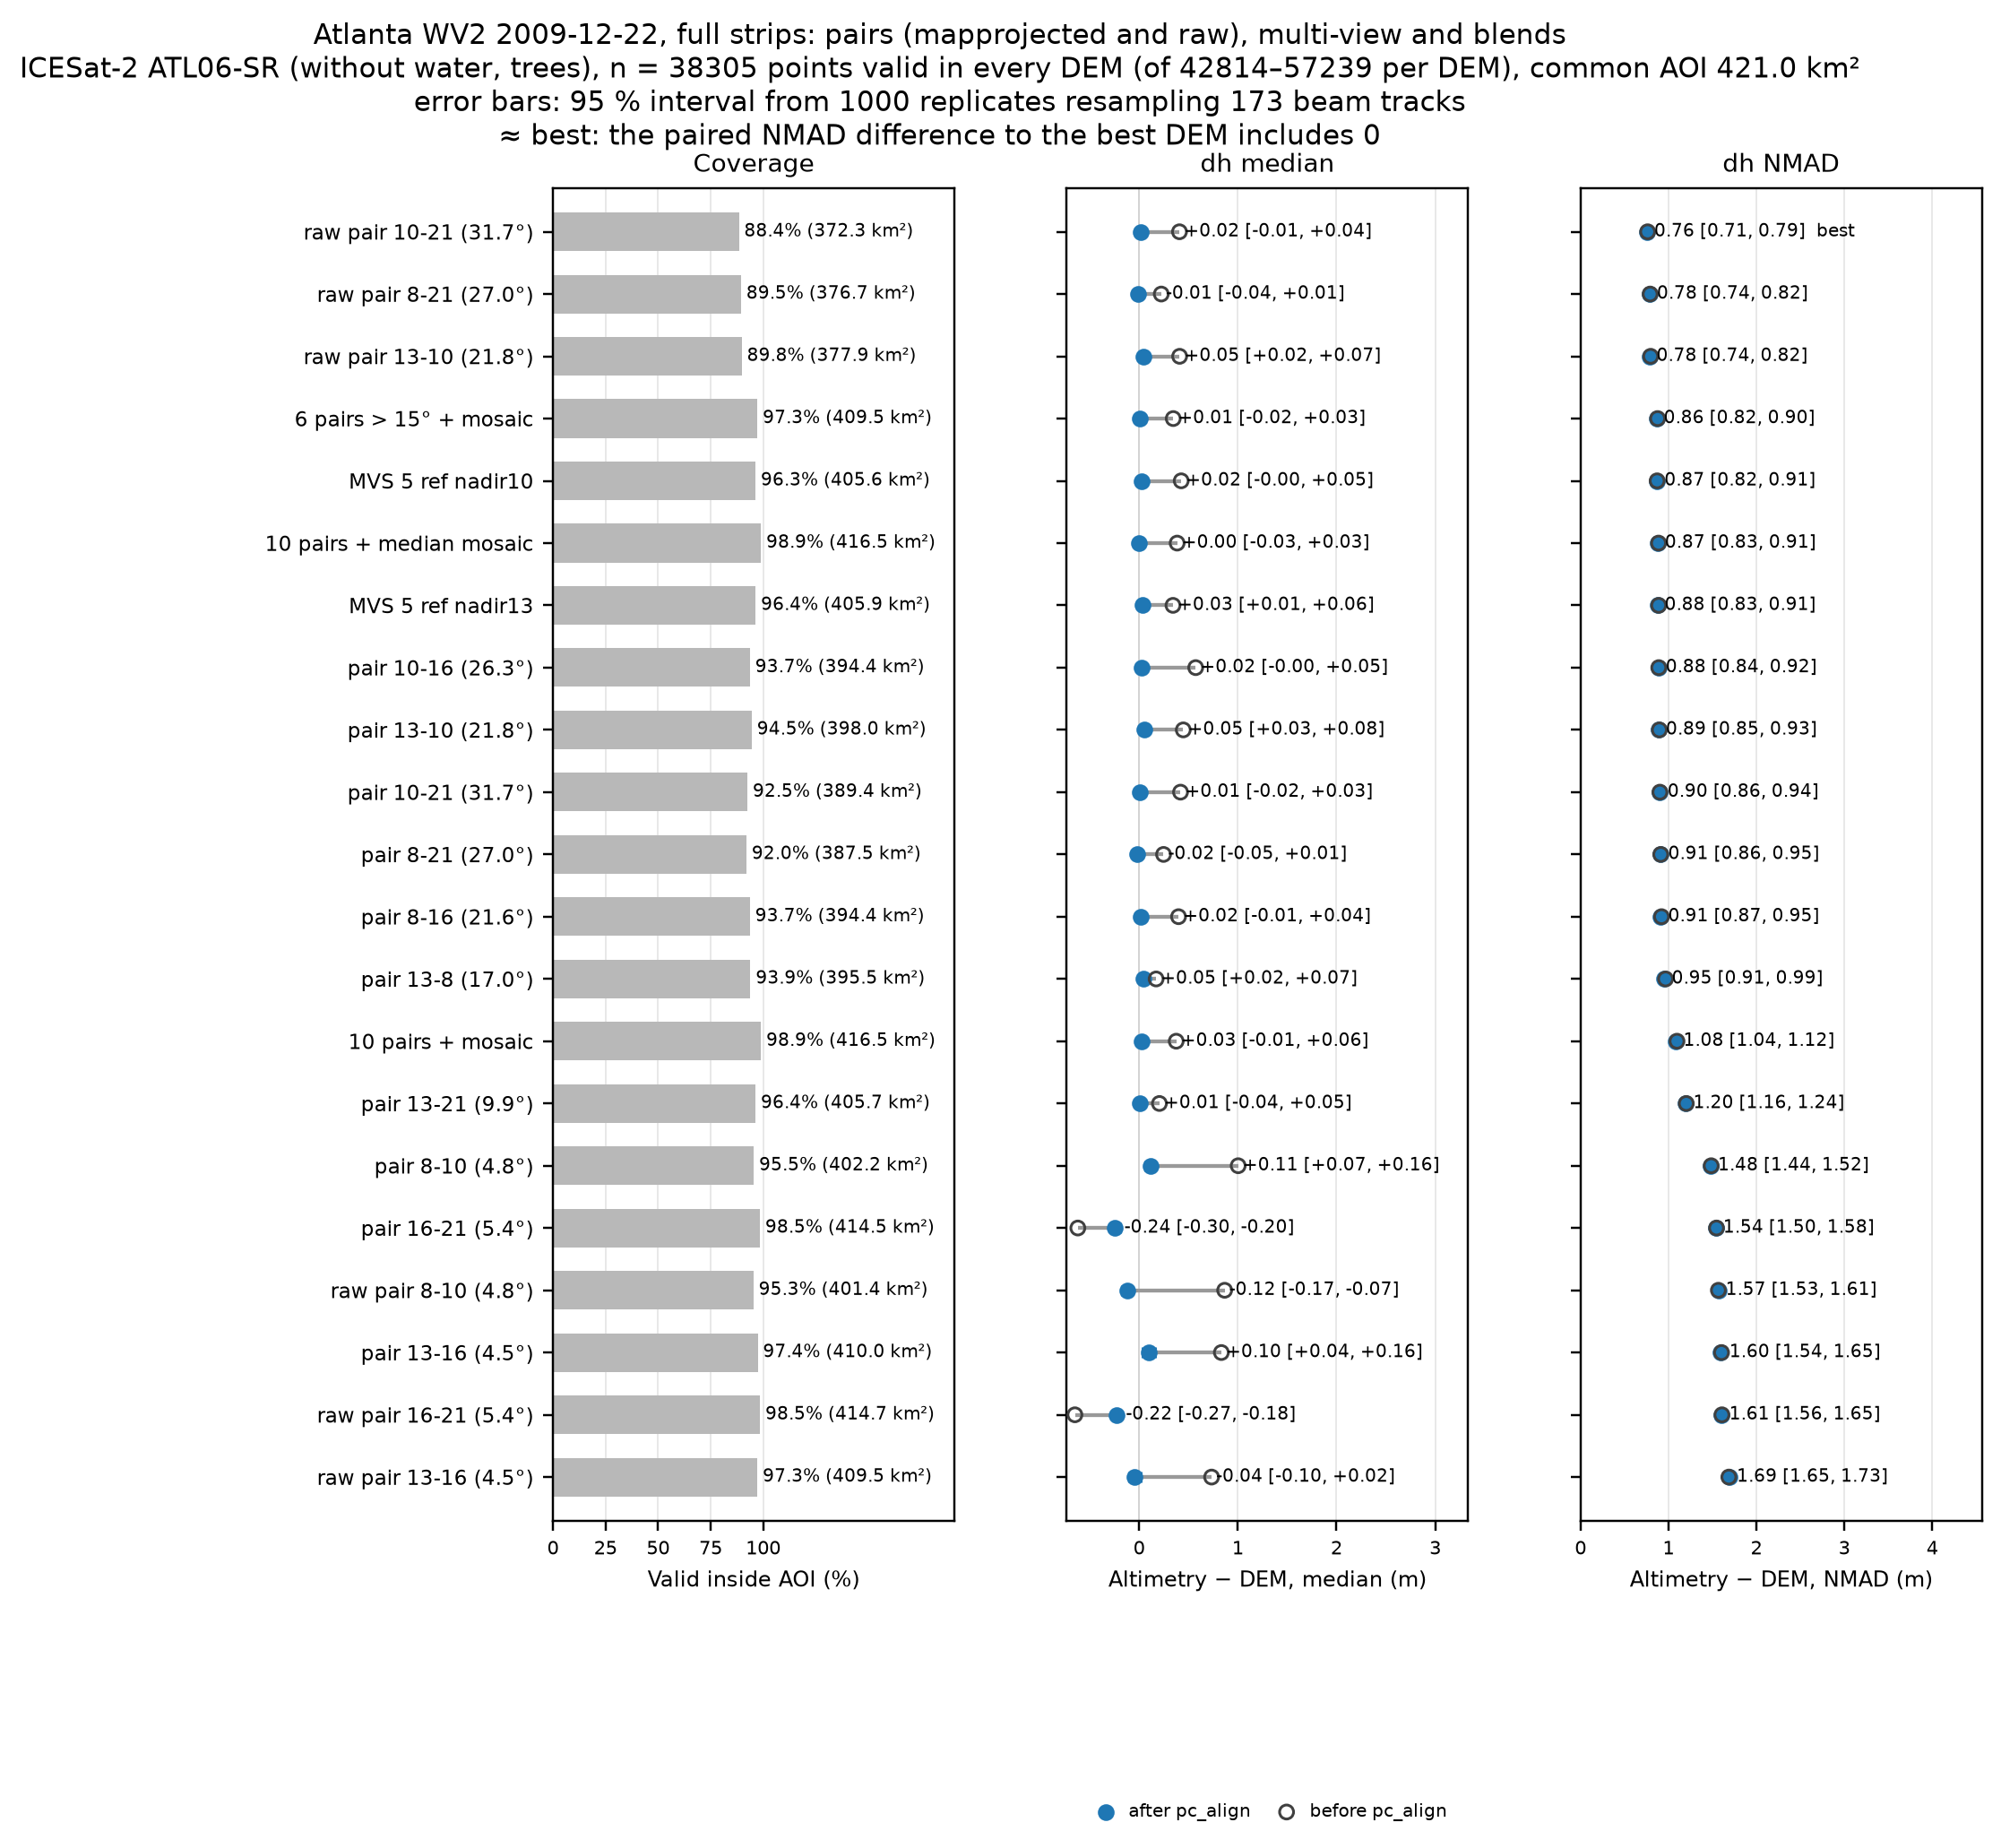

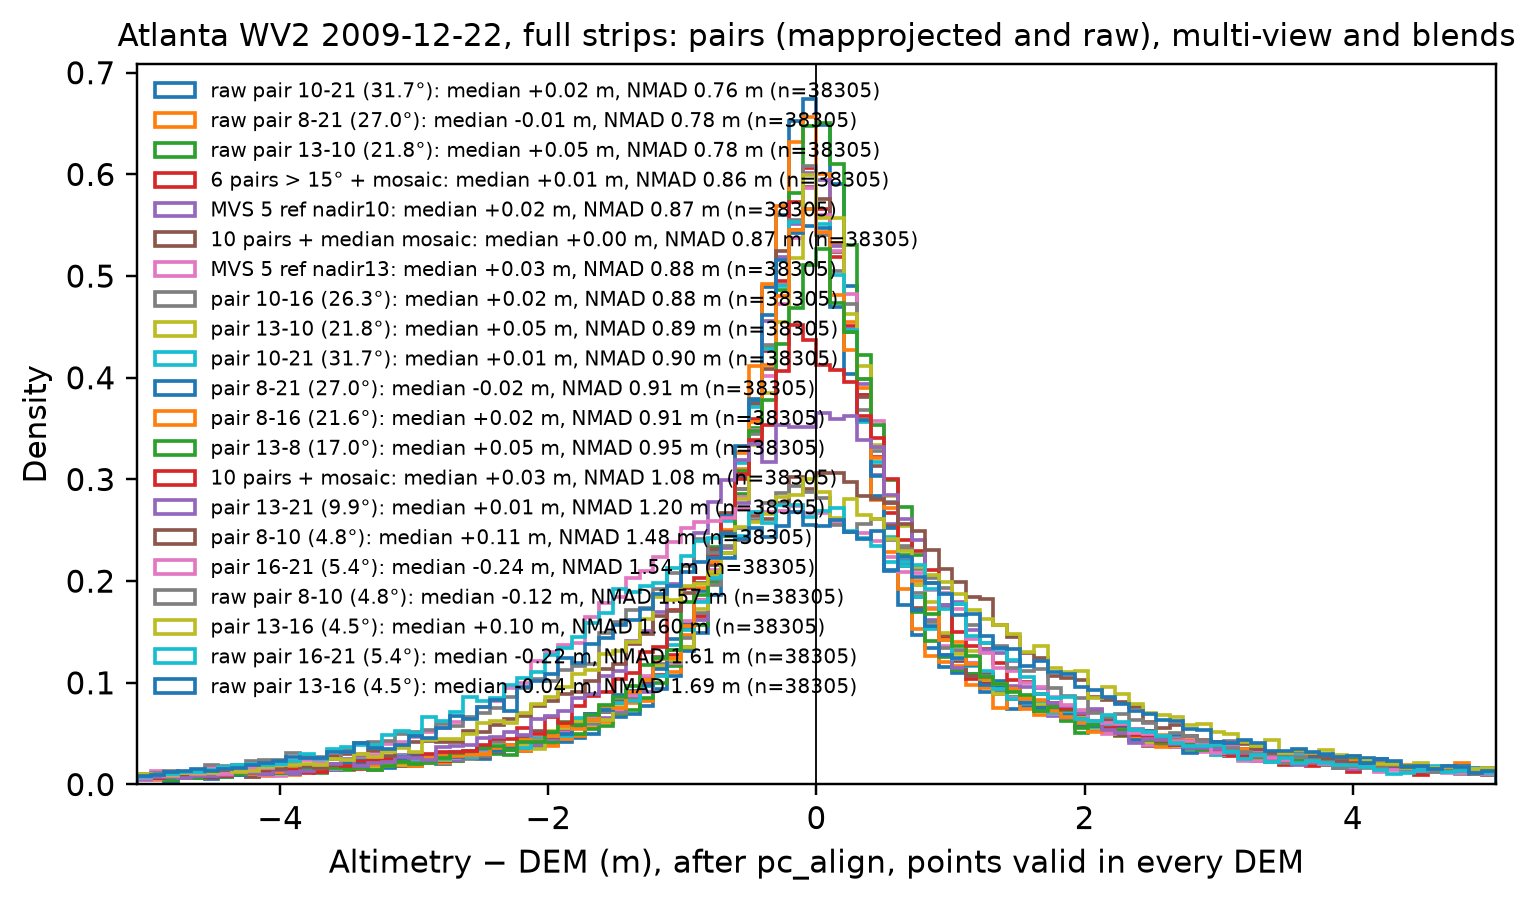

In [5]:
_ = bench.summary_plot()
_ = bench.histogram_plot()

---

## Rule 3 — single-pair accuracy vs. convergence angle

Mapprojected pairs (all ten) and raw pairs (six) on one axis, each scored after its own `pc_align` translation. The cropped study's curve is drawn for reference, but it was scored on a different sample (the airport window, water dropped), so compare its shape, not its level. The like-for-like comparison is in the section on the cropped window.

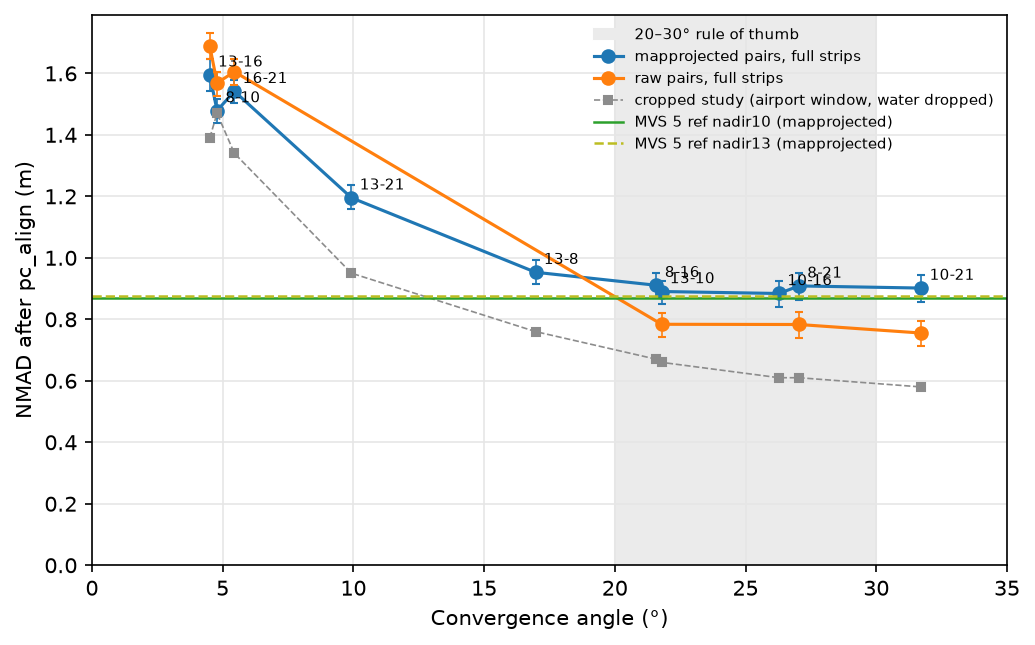

In [6]:
import re

import matplotlib.pyplot as plt

by = stats.set_index("label")
col = "dh_aligned_shared_nmad_m"
# The cropped study (worldview_spacenet_benchmark.ipynb): shared-point NMAD after pc_align
CROP = {
    "pairs": {"8-10": 1.47, "13-16": 1.39, "16-21": 1.34, "13-21": 0.95, "13-8": 0.76,
              "8-16": 0.67, "13-10": 0.66, "8-21": 0.61, "10-16": 0.61, "10-21": 0.58},
    "MVS 5 ref nadir13": 0.61, "MVS 5 ref nadir10": 0.53, "10 pairs + mosaic": 0.87,
    "6 pairs > 15° + mosaic": 0.57, "10 pairs + median mosaic": 0.58,
}


def pair_of(label):
    return re.search(r"pair (\S+) \(", label).group(1)


def pairs_table(prefix):
    p = by[by.index.str.startswith(prefix)].copy()
    p["pair"] = [pair_of(lbl) for lbl in p.index]
    p["convergence"] = p["pair"].map(conv_of)
    return p.sort_values("convergence")


map_pairs, raw_pairs = pairs_table("pair "), pairs_table("raw pair ")
crop_pairs = pd.Series(CROP["pairs"]).rename(index=lambda p: p if p in conv_of else "-".join(p.split("-")[::-1]))

fig, ax = plt.subplots(figsize=(7, 4.4), dpi=150)
ax.axvspan(20, 30, color="0.92", zorder=0, label="20–30° rule of thumb")
for p, color, name in ((map_pairs, "tab:blue", "mapprojected"), (raw_pairs, "tab:orange", "raw")):
    ax.plot(p["convergence"], p[col], "o-", color=color, label=f"{name} pairs, full strips")
    ax.errorbar(p["convergence"], p[col], fmt="none", ecolor=color, capsize=2, lw=0.8,
                yerr=[p[col] - p["nmad_ci_low_m"], p["nmad_ci_high_m"] - p[col]])
for pr, v in map_pairs.set_index("pair")[col].items():
    ax.annotate(pr, (conv_of[pr], v), textcoords="offset points", xytext=(4, 4), fontsize=7)
cp = crop_pairs.to_frame("nmad").assign(convergence=crop_pairs.index.map(conv_of)).sort_values("convergence")
ax.plot(cp["convergence"], cp["nmad"], "s--", color="0.55", ms=4, lw=0.8, label="cropped study (airport window, water dropped)")
for lbl, ls_, c in (("MVS 5 ref nadir10", "-", "tab:green"), ("MVS 5 ref nadir13", "--", "tab:olive")):
    if lbl in by.index:
        ax.axhline(by.loc[lbl, col], ls=ls_, color=c, lw=1.2, label=f"{lbl} (mapprojected)")
ax.set_xlabel("Convergence angle (°)")
ax.set_ylabel("NMAD after pc_align (m)")
ax.set_xlim(0, 35)
ax.set_ylim(bottom=0)
ax.grid(color="0.9")
ax.legend(fontsize=7, frameon=False, loc="upper right")
fig.tight_layout()

---

## Rules 1 and 2 — joint multi-view against pairwise + mosaic

The same flows as the cropped study's axis 3, all mapprojected: the two five-scene multi-view runs (nadir13's star 4.5 / 9.9 / 17.0 / 21.8°, nadir10's 4.8 / 21.8 / 26.3 / 31.7°) against three blends of the ten pairs. The cropped study's NMAD for the same DEM is in the last column.

In [7]:
flows = [
    ("multi-view", "MVS 5 ref nadir10"),
    ("multi-view", "MVS 5 ref nadir13"),
    ("pairwise + mosaic", "6 pairs > 15° + mosaic"),
    ("pairwise + mosaic", "10 pairs + median mosaic"),
    ("pairwise + mosaic", "10 pairs + mosaic"),
]
cols = ["valid_pct", "n_shared", "dh_shared_median_m", "dh_aligned_shared_nmad_m", "nmad_ci_low_m", "nmad_ci_high_m",
        "nmad_vs_best_ci_low_m", "nmad_vs_best_ci_high_m", "p_best"]
rows = []
for flow, lbl in flows:
    row = {"flow": flow, "DEM": lbl}
    row |= by.loc[lbl, cols].to_dict() if lbl in by.index else {"valid_pct": np.nan}
    row["cropped study NMAD"] = CROP[lbl]
    rows.append(row)
pd.DataFrame(rows).set_index(["flow", "DEM"]).round(2)

valid_pct  n_shared  \
flow              DEM                                             
multi-view        MVS 5 ref nadir10             96.35   38305.0   
                  MVS 5 ref nadir13             96.41   38305.0   
pairwise + mosaic 6 pairs > 15° + mosaic        97.27   38305.0   
                  10 pairs + median mosaic      98.94   38305.0   
                  10 pairs + mosaic             98.94   38305.0   

                                            dh_shared_median_m  \
flow              DEM                                            
multi-view        MVS 5 ref nadir10                       0.43   
                  MVS 5 ref nadir13                       0.34   
pairwise + mosaic 6 pairs > 15° + mosaic                  0.35   
                  10 pairs + median mosaic                0.39   
                  10 pairs + mosaic                       0.38   

                                            dh_aligned_shared_nmad_m  \
flow              DEM                                                  
multi-view        MVS 5 ref nadir10                             0.87   
                  MVS 5 ref nadir13                             0.88   
pairwise + mosaic 6 pairs > 15° + mosaic                        0.86   
                  10 pairs + median mosaic                      0.87   
                  10 pairs + mosaic                             1.08   

                                            nmad_ci_low_m  nmad_ci_high_m  \
flow              DEM                                                       
multi-view        MVS 5 ref nadir10                  0.82            0.91   
                  MVS 5 ref nadir13                  0.83            0.91   
pairwise + mosaic 6 pairs > 15° + mosaic             0.82            0.90   
                  10 pairs + median mosaic           0.83            0.91   
                  10 pairs + mosaic                  1.04            1.12   

                                            nmad_vs_best_ci_low_m  \
flow              DEM                                               
multi-view        MVS 5 ref nadir10                          0.10   
                  MVS 5 ref nadir13                          0.10   
pairwise + mosaic 6 pairs > 15° + mosaic                     0.09   
                  10 pairs + median mosaic                   0.10   
                  10 pairs + mosaic                          0.30   

                                            nmad_vs_best_ci_high_m  p_best  \
flow              DEM                                                        
multi-view        MVS 5 ref nadir10                           0.13     0.0   
                  MVS 5 ref nadir13                           0.14     0.0   
pairwise + mosaic 6 pairs > 15° + mosaic                      0.13     0.0   
                  10 pairs + median mosaic                    0.14     0.0   
                  10 pairs + mosaic                           0.35     0.0   

                                            cropped study NMAD  
flow              DEM                                           
multi-view        MVS 5 ref nadir10                       0.53  
                  MVS 5 ref nadir13                       0.61  
pairwise + mosaic 6 pairs > 15° + mosaic                  0.57  
                  10 pairs + median mosaic                0.58  
                  10 pairs + mosaic                       0.87

---

## Raw against mapprojected on the same pairs

Six pairs exist in both modes. Same pairs, same cameras, same points; only the stereo mode differs.

In [8]:
rvm = []
for pr in raw_pairs["pair"]:
    m = map_pairs[map_pairs["pair"] == pr].iloc[0]
    r = raw_pairs[raw_pairs["pair"] == pr].iloc[0]
    rvm.append({"pair": pr, "convergence": conv_of[pr],
                "raw NMAD": r[col], "raw CI": f"[{r.nmad_ci_low_m:.2f}, {r.nmad_ci_high_m:.2f}]",
                "map NMAD": m[col], "map CI": f"[{m.nmad_ci_low_m:.2f}, {m.nmad_ci_high_m:.2f}]",
                "map − raw": m[col] - r[col],
                "raw valid %": r["valid_pct"], "map valid %": m["valid_pct"]})
pd.DataFrame(rvm).sort_values("convergence").set_index("pair").round(2)

,convergence,raw NMAD,raw CI,map NMAD,map CI,map − raw,raw valid %,map valid %
pair,,,,,,,,
13-16,4.51,1.69,"[1.65, 1.73]",1.60,"[1.54, 1.65]",-0.09,97.26,97.38
8-10,4.79,1.57,"[1.53, 1.61]",1.48,"[1.44, 1.52]",-0.09,95.35,95.54
16-21,5.45,1.61,"[1.56, 1.65]",1.54,"[1.50, 1.58]",-0.06,98.50,98.46
13-10,21.79,0.78,"[0.74, 0.82]",0.89,"[0.85, 0.93]",0.11,89.77,94.54
8-21,27.04,0.78,"[0.74, 0.82]",0.91,"[0.86, 0.95]",0.13,89.47,92.03
10-21,31.72,0.76,"[0.71, 0.79]",0.90,"[0.86, 0.94]",0.15,88.43,92.51


---

## On the cropped study's ground

Every full-strip DEM clipped to the airport box (UTM 16N 735685–741350 E, 3722295–3727695 N) and scored as the cropped study scored its DEMs: water dropped, the points valid in every DEM. This separates the effect of the extent from the effect of the processing: if a clipped full-strip DEM scores like the cropped DEM of the same run, the larger extent changed nothing on that ground, and any difference in the full-strip ranking comes from the rest of the strip.

In [9]:
import rasterio
from rasterio.windows import from_bounds

CROP_BOX = (735685, 3722295, 741350, 3727695)
clip_dir = f"{directory}cropwin/"
os.makedirs(clip_dir, exist_ok=True)


def clip(label, fn):
    """Clip a DEM (and its IntersectionErr, which dem_benchmark pairs by name) to the crop box."""
    out_dir = f"{clip_dir}{re.sub(r'[^A-Za-z0-9]+', '_', label).strip('_')}/"
    os.makedirs(out_dir, exist_ok=True)
    for src_fn, dst_fn in ((fn, f"{out_dir}run-DEM.tif"),
                           (fn.replace("-DEM.tif", "-IntersectionErr.tif"), f"{out_dir}run-IntersectionErr.tif")):
        if not os.path.exists(src_fn) or os.path.exists(dst_fn):
            continue
        with rasterio.open(src_fn) as src:
            win = from_bounds(*CROP_BOX, transform=src.transform).round_offsets().round_lengths()
            prof = src.profile | {"width": win.width, "height": win.height,
                                  "transform": src.window_transform(win), "compress": "lzw", "tiled": True}
            with rasterio.open(dst_fn, "w", **prof) as dst:
                dst.write(src.read(window=win, boundless=True, fill_value=src.nodata))
    return f"{out_dir}run-DEM.tif"


clipped = {label: clip(label, fn) for label, fn in existing.items()}
bench_w = DEMBenchmark(
    directory=clip_dir,
    dems=clipped,
    parquet=f"{directory}atl06sr_all.parquet",
    reference="MVS 5 ref nadir13",
    title="Full-strip DEMs clipped to the cropped study's window (water dropped, as there)",
)
stats_w = run_quietly(bench_w)
by_w = stats_w.set_index("label")
crop_of = lambda lbl: CROP["pairs"].get(pair_of(lbl), CROP["pairs"].get("-".join(pair_of(lbl).split("-")[::-1]))) if "pair " in lbl else CROP.get(lbl)
cmp_w = pd.DataFrame({
    "clipped full strip": by_w[col],
    "CI": [f"[{a:.2f}, {b:.2f}]" for a, b in zip(by_w["nmad_ci_low_m"], by_w["nmad_ci_high_m"])],
    "cropped study": [crop_of(lbl) for lbl in by_w.index],
    "valid %": by_w["valid_pct"],
})
cmp_w["clipped − cropped"] = cmp_w["clipped full strip"] - cmp_w["cropped study"]
cmp_w.sort_values("clipped full strip").round(2)

=== [1/21] pair 13-16 (4.5°): /nobackup/bpurint1/data/atlanta/WV/20091222_spacenet/full_benchmark/cropwin/pair_13_16_4_5/run-DEM.tif
  6039 altimetry points: median +0.55 m, NMAD 1.21 m
  after pc_align (|t| = 0.66 m): median +0.03 m, NMAD 1.21 m
=== [2/21] pair 8-10 (4.8°): /nobackup/bpurint1/data/atlanta/WV/20091222_spacenet/full_benchmark/cropwin/pair_8_10_4_8/run-DEM.tif
  6010 altimetry points: median +0.95 m, NMAD 1.27 m
  after pc_align (|t| = 0.93 m): median +0.08 m, NMAD 1.28 m
=== [3/21] pair 16-21 (5.4°): /nobackup/bpurint1/data/atlanta/WV/20091222_spacenet/full_benchmark/cropwin/pair_16_21_5_4/run-DEM.tif
  6032 altimetry points: median -1.15 m, NMAD 1.36 m
  after pc_align (|t| = 1.18 m): median -0.03 m, NMAD 1.36 m
=== [4/21] pair 13-21 (9.9°): /nobackup/bpurint1/data/atlanta/WV/20091222_spacenet/full_benchmark/cropwin/pair_13_21_9_9/run-DEM.tif
  5999 altimetry points: median -0.28 m, NMAD 0.93 m
  after pc_align (|t| = 0.47 m): median +0.02 m, NMAD 0.93 m
=== [5/21] pai

,clipped full strip,CI,cropped study,valid %,clipped − cropped
label,,,,,
raw pair 8-21 (27.0°),0.51,"[0.43, 0.62]",0.61,97.77,-0.10
raw pair 10-21 (31.7°),0.52,"[0.44, 0.63]",0.58,96.90,-0.06
MVS 5 ref nadir10,0.54,"[0.44, 0.64]",0.53,99.50,0.01
pair 8-21 (27.0°),0.56,"[0.46, 0.66]",0.61,98.56,-0.05
raw pair 13-10 (21.8°),0.57,"[0.48, 0.68]",0.66,97.41,-0.09
6 pairs > 15° + mosaic,0.57,"[0.46, 0.67]",0.57,99.81,0.00
10 pairs + median mosaic,0.57,"[0.47, 0.67]",0.58,99.99,-0.01
MVS 5 ref nadir13,0.58,"[0.47, 0.67]",0.61,99.53,-0.03
pair 10-21 (31.7°),0.58,"[0.49, 0.70]",0.58,98.07,0.00


---

## Along track: does the error vary along the strip?

A crop averages along-track camera errors out, and a `pc_align` translation cannot remove them. The aligned residuals on the shared points, binned by northing (the strips run north–south), show whether the error drifts or oscillates along the pass. A camera jitter or a residual attitude error would show as a systematic swing of the bin medians, the same in every DEM that shares the camera.

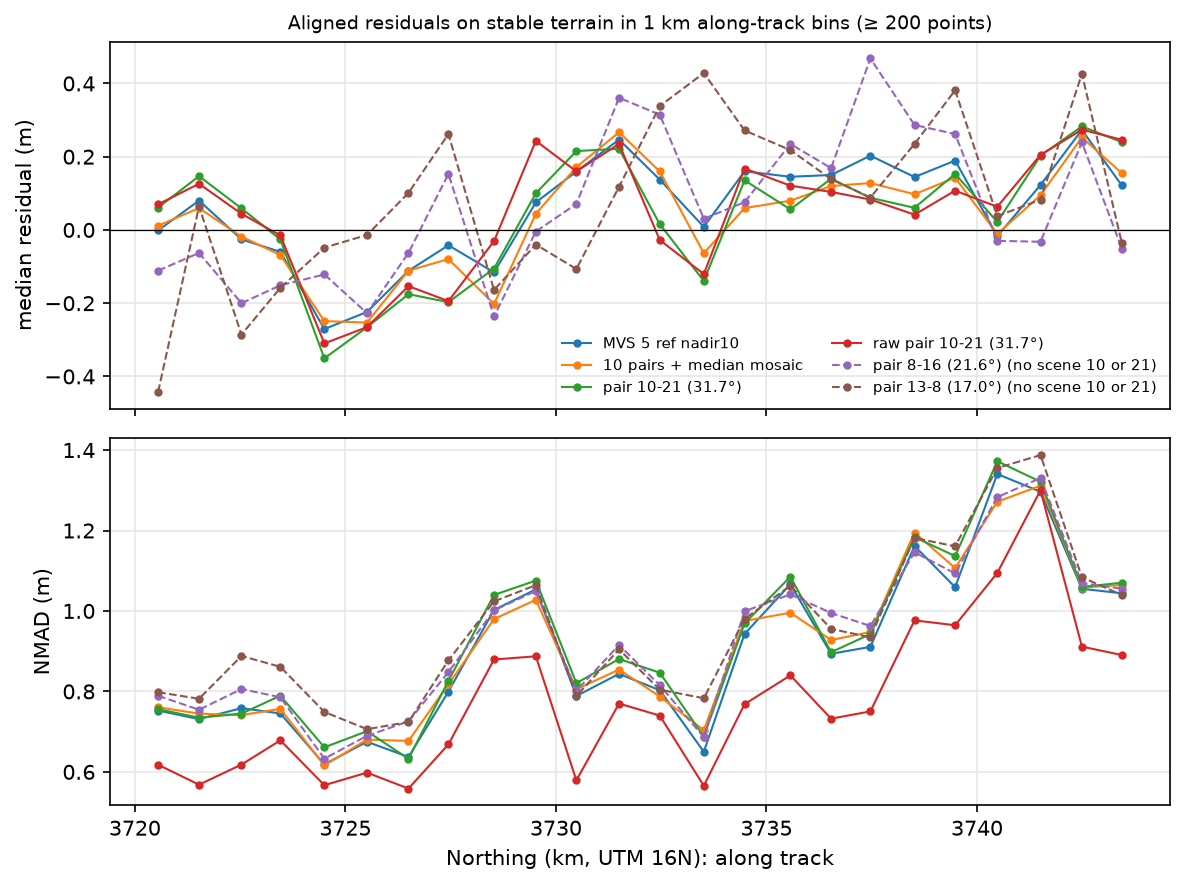

In [10]:
from asp_plot.utils import nmad

# Every DEM with scenes 10 or 21, and two pairs with neither: a swing that only the first group shows would
# point at those cameras; one that every DEM shows is common to all of them.
show = ["MVS 5 ref nadir10", "10 pairs + median mosaic", "pair 10-21 (31.7°)", "raw pair 10-21 (31.7°)",
        "pair 8-16 (21.6°)", "pair 13-8 (17.0°)"]
show = [lbl for lbl in show if lbl in by.index]
style = {lbl: ("--" if lbl in ("pair 8-16 (21.6°)", "pair 13-8 (17.0°)") else "-") for lbl in show}
bins = np.arange(3.715e6, 3.75e6 + 1, 1000)
fig, axes = plt.subplots(2, 1, figsize=(8, 6), dpi=150, sharex=True)
for lbl in show:
    p = bench.altimetry[lbl].atl06sr_processing_levels_filtered["all"]
    p = p[p["benchmark_point_id"].isin(bench.shared_ids)].to_crs("EPSG:32616")
    y, dh = p.geometry.y.values, p["icesat_minus_aligned_dem"].values
    k = np.digitize(y, bins)
    centers, med, spread, n = [], [], [], []
    for i in np.unique(k):
        sel = (k == i) & np.isfinite(dh)
        if sel.sum() >= 200:
            centers.append(np.mean(y[sel]) / 1000)
            med.append(np.median(dh[sel]))
            spread.append(nmad(dh[sel]))
    tag = " (no scene 10 or 21)" if style[lbl] == "--" else ""
    axes[0].plot(centers, med, marker="o", ls=style[lbl], ms=3, lw=1, label=lbl + tag)
    axes[1].plot(centers, spread, marker="o", ls=style[lbl], ms=3, lw=1, label=lbl + tag)
axes[0].axhline(0, color="k", lw=0.6)
axes[0].set_ylabel("median residual (m)")
axes[1].set_ylabel("NMAD (m)")
axes[1].set_xlabel("Northing (km, UTM 16N): along track")
for ax in axes:
    ax.grid(color="0.9")
axes[0].legend(fontsize=7, frameon=False, ncol=2)
axes[0].set_title("Aligned residuals on stable terrain in 1 km along-track bins (≥ 200 points)", fontsize=9)
fig.tight_layout()

---

## Takeaways

The numbers behind the key takeaways at the top, and what they change in the cropped study's practical rules for same-pass WorldView over flat terrain:

| cropped-study rule | full strips |
|---|---|
| For a multi-view run, reference a scene at one end of the pass | no measurable effect over the strip (0.87 vs 0.88 m); the choice can follow coverage or convenience |
| For a pairwise flow, drop pairs below ~15° or blend with `--median` | holds: 0.86 / 0.87 m against 1.08 m for the plain average |
| Convergence angle sets pair accuracy; aim for 20–30° | holds; past ~20° the gain is gone in both modes |

**Added by the full strips:**
- The stereo mode matters as much as the flow. Raw `affineepipolar` wide pairs (0.76–0.78 m) beat every mapprojected product, including the multi-view runs and the curated blends (0.86–0.91 m). That makes mapprojection onto COP30 at 0.5 m the most expensive accuracy choice in this study, although it is the cheaper processing route. Its cost is concentrated where COP30 departs from the imaged surface.
- Along-track camera errors of a few decimetres follow individual scenes and survive `pc_align`. Every DEM that shares a scene inherits its pattern, so neither a multi-view run nor a blend averages them out.

**Follow-ups:**
- `jitter_solve` on the five strips, then repeat the along-track check.
- Mapproject onto a better reference: a 2 m stereo DEM from these runs, or 3DEP lidar. This tests whether the raw-vs-mapprojected gap is the reference's fault.
- Run the cropped study's matrix mapprojected, so the two studies compare like with like.
- Raw multi-view runs (~110 SBU each).
- Stage-2 extras: MVS 3 / 4 for the scene-count chain, and the convergence- and `VerticalStdDev`-weighted blends.